<a href="https://colab.research.google.com/github/riya-nitnaware/riya-nitnaware.ML-LAB/blob/main/Extra_4_Riya_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:-Riya Nitnaware

USN:-CS23015




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import tree

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
path="/content/drive/MyDrive/ML_Dataset/Developer_Performance_dataset_1000.csv"
df=pd.read_csv(path)
df.head(5)

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33


In [ ]:
df.shape

(1000, 13)

In [ ]:
df.describe()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
count,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.84000,356.23400,9.876000,7.153000,2.961000,6.465800,56.933000,3.368000,66.410000,8.700100,17.253000,4.544000,56.578000
std,3.15854,188.15535,5.796052,5.468226,2.021278,1.439529,21.767506,2.342234,21.865452,5.992891,10.836901,2.820997,20.814879
min,1.00000,26.00000,0.000000,0.000000,0.000000,4.000000,20.000000,0.000000,30.000000,0.500000,1.000000,0.000000,30.000000
25%,3.00000,209.50000,5.000000,2.000000,1.000000,5.200000,38.000000,1.000000,48.000000,4.000000,9.000000,2.000000,37.000000
50%,6.00000,332.00000,10.000000,7.000000,3.000000,6.400000,57.000000,3.000000,66.000000,7.450000,14.000000,5.000000,55.500000
75%,9.00000,480.50000,15.000000,12.000000,5.000000,7.700000,76.000000,5.000000,86.000000,12.000000,23.000000,7.000000,74.000000
max,11.00000,993.00000,19.000000,19.000000,6.000000,9.000000,94.000000,7.000000,100.000000,27.500000,50.000000,9.000000,100.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Coffee_Intake        1000 non-null   int64  
 8   Stress_Level         1000 non-null   int64  
 9   Task_Duration_Hours  1000 non-null   float64
 10  Commits              1000 non-null   int64  
 11  Errors               1000 non-null   int64  
 12  Task_Success_Rate    1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [ ]:
df.columns


Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Hours_Coding,0
Lines_of_Code,0
Bugs_Found,0
Bugs_Fixed,0
AI_Usage_Hours,0
Sleep_Hours,0
Cognitive_Load,0
Coffee_Intake,0
Stress_Level,0
Task_Duration_Hours,0


In [ ]:
df.isnull().any().any()

np.False_

In [ ]:

df[df.isnull().any(axis=1)]

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate


In [ ]:
X = df.drop("Task_Success_Rate", axis=1)
y = df["Task_Success_Rate"]

X = X.values
y = y.values

In [ ]:
before_rows = df.shape[0]
df = df.dropna()
after_rows = df.shape[0]

print("before rows:", before_rows)
print("after rows:", after_rows)
print("rows dropped:", before_rows - after_rows)

before rows: 1000
after rows: 1000
rows dropped: 0


In [ ]:
df["Task_Success_Rate"].unique()

array([ 34,  36,  79,  94,  33,  39,  56,  40,  75,  30,  73,  63,  92,
        42,  82,  78,  61,  57,  51,  62,  85,  71,  84,  53,  70,  64,
        80,  87,  66,  54,  67, 100,  32,  44,  52,  50,  86,  91,  60,
        65,  72,  49,  35,  93,  43,  90,  69,  89,  31,  97,  38,  95,
        81,  83,  58,  41,  48,  55,  46,  37,  59,  88,  96,  76,  99,
        74,  77,  45,  47,  68,  98])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.7,
    test_size=0.3,
    random_state=42
)

In [ ]:
X_train

array([[  3. , 178. ,   0. , ...,   3.8,   7. ,   0. ],
       [  6. , 226. ,   5. , ...,   9.9,   8. ,   9. ],
       [  5. , 388. ,   4. , ...,   2.8,  11. ,   9. ],
       ...,
       [  1. , 102. ,  19. , ...,   1.4,   6. ,   3. ],
       [  7. , 189. ,  17. , ...,   4.1,  14. ,   2. ],
       [ 10. , 282. ,   4. , ...,  10.6,  42. ,   3. ]])

In [ ]:
X_test

array([[  3. , 234. ,   5. , ...,   1.7,   5. ,   4. ],
       [  2. , 254. ,   5. , ...,   2.3,  12. ,   8. ],
       [  5. , 266. ,  13. , ...,   6.5,  14. ,   2. ],
       ...,
       [  9. , 646. ,   8. , ...,  11.5,  11. ,   1. ],
       [  3. , 234. ,   5. , ...,   2.9,  15. ,   2. ],
       [  7. , 224. ,  19. , ...,  13. ,   8. ,   8. ]])

In [ ]:
y_test

array([ 39,  36,  36,  49,  82,  32,  69,  66,  62,  38,  53,  62,  57,
        90,  42,  30,  56,  69,  78, 100,  62,  46,  53,  53,  73,  54,
        87,  37,  61,  36,  37,  81,  57,  97,  81,  46,  72,  78,  43,
        54,  30,  72,  79,  60,  71,  78,  30,  32,  42,  77,  35,  49,
        76,  67,  51,  62,  71,  73,  30,  48,  30,  67,  56,  63,  33,
        91,  30,  58,  30,  56,  90,  81,  30,  30,  30,  91,  47,  30,
        47,  50,  38,  78,  40,  70,  79,  53,  51,  56,  43,  73,  81,
        58,  30,  30,  75,  40,  30,  40,  61,  56,  86,  61,  68,  46,
        32,  64,  97,  83,  39,  30,  30,  57,  77,  58,  91,  30,  30,
        70,  57,  41,  41,  30,  39,  41,  38,  78,  30,  62,  73,  30,
        58,  76,  99,  80,  60,  40,  30,  83,  85,  61,  84,  89,  85,
        30,  36,  66,  30,  32,  93,  49,  77,  30,  42,  44,  82,  56,
        45,  76,  30,  59,  46,  44,  71,  44,  34,  55,  30,  40,  67,
        97,  53,  30,  30,  57,  42,  72,  43,  33,  76,  53,  8

In [ ]:
y_train

array([ 85,  80,  50,  30,  74,  74,  46,  30,  93,  48,  42,  36,  30,
        58,  88,  41,  70,  89,  60,  53,  30,  79,  33,  76,  30,  47,
        30,  62,  55,  69,  30,  30,  30,  83,  34,  81,  30,  76,  78,
        30,  45,  30,  30,  43,  34,  71,  93,  86,  52,  56,  50,  87,
        79,  56,  53,  31, 100,  36,  30,  83,  30,  30,  97,  39,  48,
        71,  93,  44,  32,  35,  55,  90,  43,  31,  56,  72,  73,  34,
        78,  37,  63,  58,  92,  53,  92,  30,  64,  52,  70,  63,  46,
        78,  30,  75,  60,  51,  30,  58,  34,  74,  62,  54,  55,  38,
        52,  33,  38,  30,  33,  65,  43,  62,  79,  72,  48,  87,  40,
        89,  80,  60,  30,  61,  82,  40,  65,  43,  92,  32,  62,  30,
        31,  43,  52,  43,  78,  39,  72,  51,  46,  57,  48,  30,  83,
        90,  60,  44,  93,  30,  72,  68,  95,  30,  30,  81,  80,  30,
        42,  85,  59,  30,  52,  33,  62,  30,  32,  87,  30,  42,  30,
        31,  53,  65,  76,  84,  30,  30,  68,  87,  58,  30,  7

In [ ]:
model = tree.DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
y_pred = model.predict(X_test)
print("Predicted Values:")
print(y_pred)

Predicted Values:
[ 36.  31.  39.  42.  66.  30.  56.  67.  61.  38.  51.  47.  61.  81.
  50.  30.  58.  73.  85.  90.  58.  42.  56.  56.  62.  42.  88.  38.
  60.  31.  30.  81.  42.  90.  73.  54.  62.  87.  45.  58.  30.  87.
  90.  54.  82.  68.  30.  42.  51.  83.  37.  52.  79.  65.  41.  56.
  60.  66.  30.  43.  36.  72.  63.  66.  30.  88.  30.  62.  32.  56.
  82.  73.  30.  46.  30.  88.  46.  40.  30.  48.  46.  85.  44.  54.
  87.  53.  57.  74.  39.  58.  80.  72.  30.  30.  77.  44.  30.  30.
  54.  63.  89.  63.  60.  42.  44.  62. 100.  82.  45.  30.  44.  52.
  73.  54.  90.  37.  30.  71.  57.  30.  35.  32.  37.  50.  30.  75.
  30.  62.  73.  32.  35.  79.  84.  80.  67.  42.  30.  87.  85.  48.
  85.  85.  79.  30.  31.  60.  30.  33.  75.  52.  82.  30.  44.  51.
  80.  48.  48.  73.  44.  75.  54.  43.  57.  41.  34.  71.  30.  42.
  69. 100.  67.  31.  30.  55.  50.  85.  42.  30.  80.  39.  89.  74.
  41.  31.  76.  91.  48.  70.  79.  56.  30.  43.  30.  33

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 51.29
R2 Score: 0.872195940420788


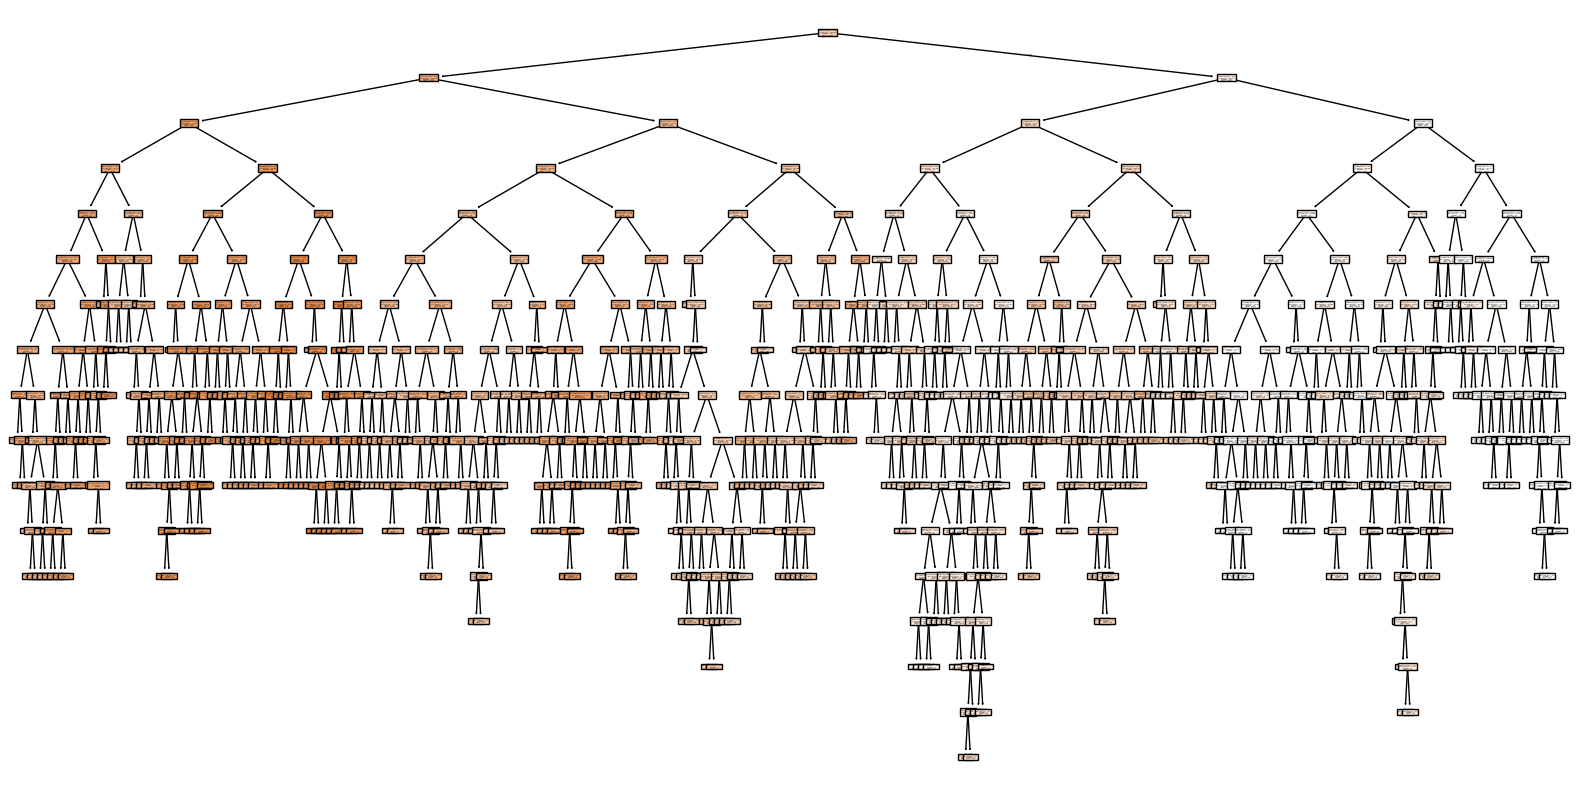

In [ ]:
plt.figure(figsize=(20,10))

tree.plot_tree(
    model,
    feature_names=df.drop("Task_Success_Rate", axis=1).columns,
    filled=True
)

plt.show()